In [3]:
# Imports and setup
import sys
from pathlib import Path

# Ensure project root is on sys.path so we can import src.test_strategy
proj_root = Path('..').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.test_strategy import test_strategy

plt.rcParams['figure.figsize'] = (12, 6)


In [4]:
df = pd.read_csv('../tests/DnB Stock Price History.csv', parse_dates=['Date'], index_col='Date')[::-1]

In [5]:
def MA_scorer(df):
    """
    Score the momentum based on moving average crossovers.
    
    Buy signals (positive):
    - SMA50 > SMA100: 1
    - SMA50 > SMA200: 2
    - SMA50 > SMA100 > SMA200: 3
    - Price > SMA50 > SMA100 > SMA200: 4
    
    Sell signals (negative):
    - SMA100 > SMA50: -1
    - SMA200 > SMA50: -2
    - SMA200 > SMA100 > SMA50: -3
    - SMA200 > SMA100 > SMA50 > Price: -4
    
    Args:
        df: DataFrame with 'Price' column and optionally 'SMA50', 'SMA100', 'SMA200'
    
    Returns:
        Series with MA scores from -4 to 4
    """
    # Calculate SMAs if not present
    df_copy = df.copy()
    if 'SMA50' not in df_copy.columns:
        df_copy['SMA50'] = df_copy['Price'].rolling(window=50).mean()
    if 'SMA100' not in df_copy.columns:
        df_copy['SMA100'] = df_copy['Price'].rolling(window=100).mean()
    if 'SMA200' not in df_copy.columns:
        df_copy['SMA200'] = df_copy['Price'].rolling(window=200).mean()
    
    def score_row(row):
        price = row['Price']
        sma50 = row['SMA50']
        sma100 = row['SMA100']
        sma200 = row['SMA200']
        
        # Handle NaN values
        if pd.isna(sma50) or pd.isna(sma100) or pd.isna(sma200):
            return 0
        
        # BUY signals (positive scores) - check most specific first
        if price > sma50 > sma100 > sma200:
            return 4
        if sma50 > sma100 > sma200:
            return 3
        if sma50 > sma200:
            return 2
        if sma50 > sma100:
            return 1
        
        # SELL signals (negative scores) - check most specific first
        if sma200 > sma100 > sma50 > price:
            return -4
        if sma200 > sma100 > sma50:
            return -3
        if sma200 > sma50:
            return -2
        if sma100 > sma50:
            return -1
        
        return 0
    
    return df_copy.apply(score_row, axis=1)

In [6]:
scored_df = df.copy()
scored_df['MA_Score'] = MA_scorer(scored_df)
scored_df[scored_df['MA_Score'] == 0]

,Price,Open,High,Low,Vol.,Change %,MA_Score
Date,,,,,,,
2009-02-09,27.30,27.50,27.75,27.30,NaN,16.92%,0
2009-02-12,25.30,28.20,28.35,25.30,NaN,-7.33%,0
2009-02-13,23.20,26.10,26.10,23.20,NaN,-8.30%,0
2009-02-16,24.45,23.80,24.45,23.80,NaN,5.39%,0
2009-02-17,21.60,23.10,23.25,21.60,NaN,-11.66%,0
...,...,...,...,...,...,...,...
2010-02-02,65.43,65.43,65.43,65.43,NaN,0.00%,0
2010-02-05,65.43,65.43,65.43,65.43,NaN,0.00%,0
2010-02-09,65.43,65.43,65.43,65.43,NaN,0.00%,0


In [7]:
def trade_ma_strategy(df, initial_capital=1_000_000, transaction_cost=0.00035):
    """
    Trading strategy based on MA_Score signals with lagged execution.
    
    Args:
        df: DataFrame with 'Price' price and 'MA_Score' columns
        initial_capital: Initial portfolio value in NOK (default: 1,000,000)
        transaction_cost: Transaction cost as decimal (default: 0.035% = 0.00035)
    
    Allocation rules:
        Positive signals: 1->25%, 2->50%, 3->75%, 4->100%
        Negative signals: -1->reduce to 75%, -2->50%, -3->25%, -4->0%
        0: do nothing
    
    Returns:
        DataFrame with daily returns, cumulative returns, and position details
    """
    df_trade = df.copy()
    
    # Calculate log returns of underlying stock
    df_trade['Log_Returns'] = np.log(df_trade['Price'] / df_trade['Price'].shift(1))
    
    # Shift signals by 1 day (trade on lagged signals)
    df_trade['Signal'] = df_trade['MA_Score'].shift(1)
    
    # Define target allocation percentages based on signal
    def get_target_allocation(signal):
        if pd.isna(signal):
            return 0
        signal = int(signal)
        if signal == 4:
            return 1.0
        elif signal == 3:
            return 0.75
        elif signal == 2:
            return 0.5
        elif signal == 1:
            return 0.25
        elif signal == -1:
            return 0.75
        elif signal == -2:
            return 0.5
        elif signal == -3:
            return 0.25
        elif signal == -4:
            return 0.0
        else:  # signal == 0
            return None  # Do nothing
    
    df_trade['Target_Allocation'] = df_trade['Signal'].apply(get_target_allocation)
    
    # Initialize tracking variables
    portfolio_value = initial_capital
    shares_held = 0
    position_value = 0
    cash = initial_capital
    
    portfolios = []
    
    for idx, row in df_trade.iterrows():
        current_price = row['Price']
        target_alloc = row['Target_Allocation']
        
        # Process signal and adjust position
        if pd.notna(target_alloc):  # If signal requires action
            target_position_value = portfolio_value * target_alloc
            
            # Calculate shares needed
            target_shares = target_position_value / current_price if current_price > 0 else 0
            
            # Calculate transaction
            shares_diff = target_shares - shares_held
            
            if shares_diff != 0:
                # Transaction cost on value of shares traded
                transaction_value = abs(shares_diff * current_price)
                transaction_fee = transaction_value * transaction_cost
                
                # Update shares and cash
                shares_held = target_shares
                position_value = shares_held * current_price
                cash = portfolio_value - position_value - transaction_fee
                portfolio_value = cash + position_value
            else:
                position_value = shares_held * current_price
        else:
            # No action signal - just update position value based on price movement
            position_value = shares_held * current_price
        
        # Calculate daily return (using log return of stock, not portfolio)
        daily_log_return = row['Log_Returns']
        
        # Store results
        portfolios.append({
            'Date': idx,
            'Price': current_price,
            'Signal': row['Signal'],
            'Target_Allocation': target_alloc,
            'Shares_Held': shares_held,
            'Position_Value': position_value,
            'Cash': cash,
            'Portfolio_Value': portfolio_value,
            'Daily_Log_Return': daily_log_return,
            'Portfolio_Return': (portfolio_value / initial_capital - 1) if portfolio_value > 0 else 0
        })
    
    result_df = pd.DataFrame(portfolios)
    result_df.set_index('Date', inplace=True)
    
    # Calculate cumulative return
    result_df['Cumulative_Return'] = result_df['Portfolio_Return']
    
    return result_df

# Apply the strategy
strategy_results = trade_ma_strategy(scored_df)


                            OLS Regression Results                            
Dep. Variable:           excess_strat   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     2968.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:41:52   Log-Likelihood:                 11083.
No. Observations:                3931   AIC:                        -2.216e+04
Df Residuals:                    3929   BIC:                        -2.215e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -0.747      0.4

{'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x26a73e34c40>,
 'series': {'strategy_log': Date
  2009-02-12   -0.079132
  2009-02-13   -0.090638
  2009-02-16    0.051147
  2009-02-17   -0.132317
  2009-02-18    0.029218
                  ...   
  2026-01-23   -0.006475
  2026-01-26    0.009619
  2026-01-27    0.007777
  2026-01-28   -0.014343
  2026-01-29   -0.005045
  Name: strategy, Length: 4095, dtype: float64,
  'strategy_simple': Date
  2009-02-12   -0.076082
  2009-02-13   -0.086652
  2009-02-16    0.052478
  2009-02-17   -0.123937
  2009-02-18    0.029649
                  ...   
  2026-01-23   -0.006454
  2026-01-26    0.009665
  2026-01-27    0.007807
  2026-01-28   -0.014240
  2026-01-29   -0.005032
  Name: strategy_simple, Length: 4095, dtype: float64,
  'market_log': Date
  2009-02-12   -0.028914
  2009-02-13    0.017250
  2009-02-16   -0.018877
  2009-02-17   -0.031181
  2009-02-18   -0.014403
                  ...   
  2026-01-23         NaN
 

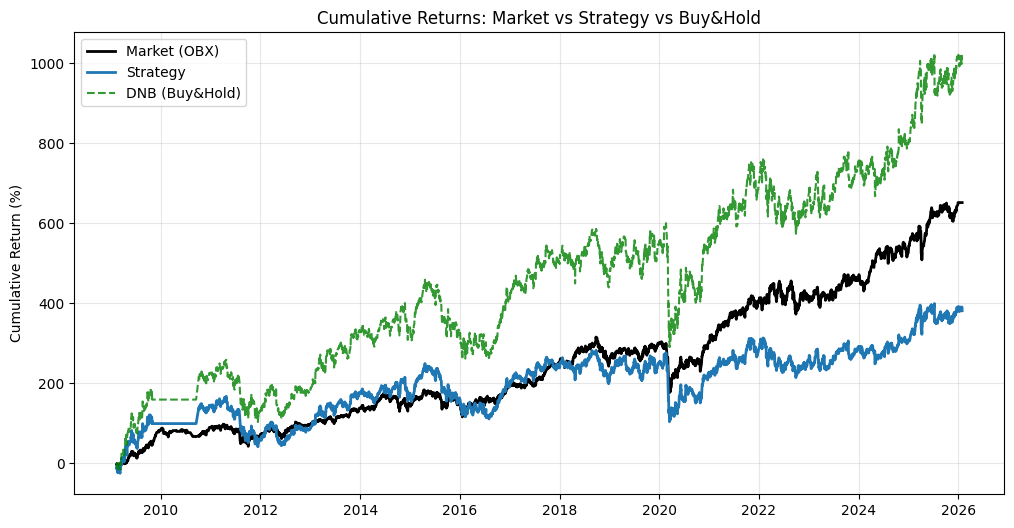

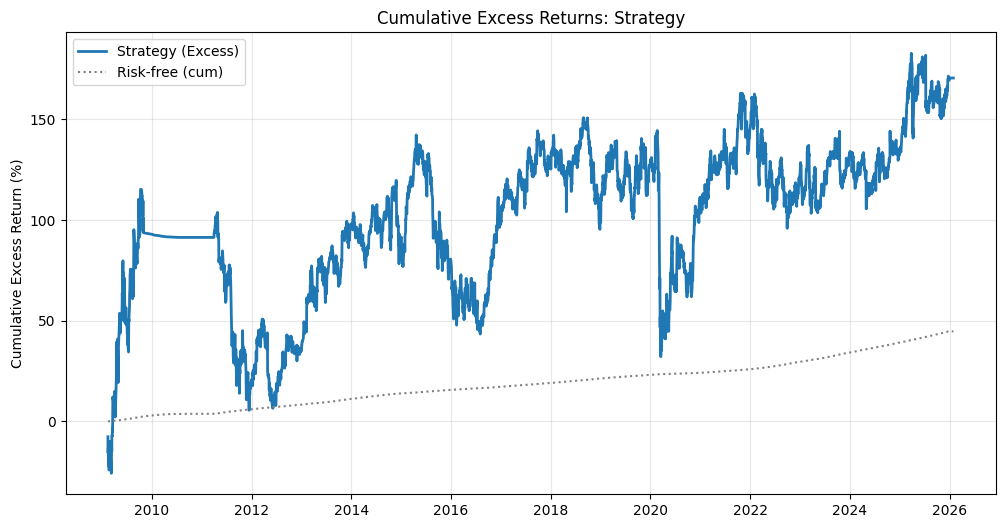

In [9]:
# Run test_strategy on daily returns
# Get prices aligned with strategy results (skip first row to match log returns)
prices = scored_df.loc[strategy_results.index[1:], 'Price'].values
daily_returns = strategy_results['Daily_Log_Return'].iloc[1:].values

test_strategy(
    strategy_returns=daily_returns,
    underlying_prices=[prices],
    underlying_names=['DNB'],
    dates=strategy_results.index[1:],
    data_dir=str(proj_root / 'data' / 'processed'),
    plot_index=True,
)